# Install dependencies

In [1]:
!pip install git+https://github.com/huggingface/transformers.git
!pip install pymupdf

!apt-get install poppler-utils
!pip install pytesseract opencv-python pdf2image pillow numpy

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-svq6v_pe
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-svq6v_pe
  Resolved https://github.com/huggingface/transformers.git to commit 5b565a589ca5935fbc7a3ea93b9b622bb41bd129
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.6.0.dev0-py3-none-any.whl size=11420994 sha256=6fe1134c260e30531564976393caf3eae73b2fef54fa5e8445ea7e5e0c0acc00
  Stored in directory: /tmp/pip-ephem-wheel-cache-l1yf2nxg/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#Import libraries

In [6]:
# imports


import glob
# import math
import io
import shutil
import os
import csv
# import json
import requests

import cv2
from PIL import Image
from pdf2image import convert_from_path
import pytesseract
from pytesseract import Output
import pymupdf

from tqdm.notebook import tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
# from numba import cuda
from transformers import AutoProcessor, AutoModelForImageTextToText

from google.colab.patches import cv2_imshow

#Import the test PDF document
We will be working with "Sumerian Liturgies and Psalms, part 4 of 10". The book is available free of charge and can be dowloaded from Project Gutenberg website.

In [7]:
TEST_PDF="https://www.gutenberg.org/files/31935/31935-pdf.pdf"   # "Sumerian Liturgies and Psalms, 4/10"
TEST_PDF_FILENAME="./Sumerian-Liturgies-and-Psalms-4-of-10.pdf"

raw_pdf = requests.get(TEST_PDF).content
with open(TEST_PDF_FILENAME, mode='wb') as f:
    f.write(raw_pdf)

# Initiate functions

In [20]:
def get_pdf_page_image(pdf_path, page_number, dpi=300):
    """Extracts a page from a PDF as a PIL Image."""
    try:
        doc = pymupdf.open(pdf_path)
        # PyMuPDF is 0-indexed
        page = doc.load_page(page_number - 1)
        pix = page.get_pixmap(dpi=dpi)
        img_data = pix.tobytes("png")
        return Image.open(io.BytesIO(img_data))
    except Exception as e:
        print(f"PyMuPDF failed, falling back to pdf2image: {e}")
        try:
            images = convert_from_path(pdf_path, first_page=page_number, last_page=page_number, dpi=dpi)
            return images[0]
        except Exception as e2:
            print(f"pdf2image failed: {e2}")
            return None

def extract_fields_mod(pdf_path, page_num, output_dir, psm=3, show_bounds=True):
    # Setup Output Directory
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)

    # 1. Load Image
    pil_img = get_pdf_page_image(pdf_path, page_num)
    if pil_img is None:
        print("Error: Could not load image.")
        return None

    img = np.array(pil_img)
    # Handle Grayscale
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Prepare inverted binary image for ink detection (Text=255, Bg=0)
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, bin_inv = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    h_img, w_img = bin_inv.shape

    # --- Preprocessing for Tesseract (Adaptive Threshold) ---
    # Use img_gray as input (must be single channel uint8)
    img = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

    # 2. Tesseract Layout Analysis
    print("Running Tesseract layout analysis...")
    custom_config = r'' + f'--psm {psm}'
    try:
        d = pytesseract.image_to_data(img, config=custom_config, output_type=Output.DICT)
    except Exception as e:
        print(f"Tesseract Error: {e}")
        return

    # 3. Group Text into Fields
    # Group by (Block, Para, Line) to respect column splits
    lines_map = {}
    n_boxes = len(d['level'])

    for i in range(n_boxes):
        if d['level'][i] != 5: # Word level
            continue
        text = d['text'][i].strip()
        if not text:
            continue

        key = (d['block_num'][i], d['par_num'][i], d['line_num'][i])

        if key not in lines_map:
            lines_map[key] = []

        lines_map[key].append({
            'left': d['left'][i],
            'top': d['top'][i],
            'width': d['width'][i],
            'height': d['height'][i]
        })

    raw_fields = []
    for key, boxes in lines_map.items():
        x1 = min(b['left'] for b in boxes)
        y1 = min(b['top'] for b in boxes)
        x2 = max(b['left'] + b['width'] for b in boxes)
        y2 = max(b['top'] + b['height'] for b in boxes)
        raw_fields.append((x1, y1, x2 - x1, y2 - y1))

    # 4. Refine Fields: Expand borders if cutting through ink
    refined_fields = []
    for (x, y, w, h) in raw_fields:
        # Calculate max pixel value for half-height along the entire length
        mid_y = min(max(y + h // 2, 0), h_img - 1)
        mid_row = bin_inv[mid_y, x:x+w]

        if len(mid_row) == 0:
            refined_fields.append((x, y, w, h))
            continue

        max_px_val = np.max(mid_row)

        # If the center line has no ink (value 0), do not expand
        if max_px_val == 0:
            refined_fields.append((x, y, w, h))
            continue

        cur_x, cur_y, cur_w, cur_h = x, y, w, h

        # --- TIGHTENING LOGIC: Shrink box to fit text ---
        # Top
        while cur_h > 1:
            check_row = bin_inv[cur_y, cur_x : cur_x + cur_w]
            if not np.any(check_row == max_px_val):
                cur_y += 1
                cur_h -= 1
            else:
                break

        # Bottom
        while cur_h > 1:
            check_row = bin_inv[cur_y + cur_h - 1, cur_x : cur_x + cur_w]
            if not np.any(check_row == max_px_val):
                cur_h -= 1
            else:
                break

        # Left
        while cur_w > 1:
            check_col = bin_inv[cur_y : cur_y + cur_h, cur_x]
            if not np.any(check_col == max_px_val):
                cur_x += 1
                cur_w -= 1
            else:
                break

        # Right
        while cur_w > 1:
            check_col = bin_inv[cur_y : cur_y + cur_h, cur_x + cur_w - 1]
            if not np.any(check_col == max_px_val):
                cur_w -= 1
            else:
                break

        # --- EXPANSION LOGIC ---
        # Recursively increase border by 2px (max 10px)
        max_add = 10
        step_size = 1

        # Top
        for _ in range(0, max_add, step_size):
            if cur_y <= 0: break
            check_row = bin_inv[cur_y, cur_x : cur_x + cur_w]
            if np.any(check_row == max_px_val):
                step = min(step_size, cur_y)
                cur_y -= step
                cur_h += step
            else:
                break

        # Bottom
        for _ in range(0, max_add, step_size):
            if cur_y + cur_h >= h_img: break
            check_row = bin_inv[cur_y + cur_h - 1, cur_x : cur_x + cur_w]
            if np.any(check_row == max_px_val):
                step = min(step_size, h_img - (cur_y + cur_h))
                cur_h += step
            else:
                break

        # Left
        for _ in range(0, max_add, step_size):
            if cur_x <= 0: break
            check_col = bin_inv[cur_y : cur_y + cur_h, cur_x]
            if np.any(check_col == max_px_val):
                step = min(step_size, cur_x)
                cur_x -= step
                cur_w += step
            else:
                break

        # Right
        for _ in range(0, max_add, step_size):
            if cur_x + cur_w >= w_img: break
            check_col = bin_inv[cur_y : cur_y + cur_h, cur_x + cur_w - 1]
            if np.any(check_col == max_px_val):
                step = min(step_size, w_img - (cur_x + cur_w))
                cur_w += step
            else:
                break

        refined_fields.append((cur_x, cur_y, cur_w, cur_h))

    # 5. Sort Fields (Top-to-Bottom, then Left-to-Right)
    refined_fields.sort(key=lambda box: (box[1] // 20, box[0]))

    # 6. Process: Save & visualize
    vis_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) # Create BGR for visualization since img is now gray/binary

    csv_path = os.path.join(output_dir, "metadata.csv")
    with open(csv_path, 'w', newline='') as csvfile:
        fieldnames = ['page_num', 'field_num', 'x', 'y', 'w', 'h']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

        writer.writerow({'page_num': page_num, 'field_num': -1, 'x': 0, 'y': 0, 'w': img.shape[1], 'h': img.shape[0]})

        for idx, (x, y, w, h) in enumerate(refined_fields):
            # Save crop
            filename = f"p-{page_num}_f-{idx}.png"
            filepath = os.path.join(output_dir, filename)
            crop = img[y:y+h, x:x+w]
            cv2.imwrite(filepath, crop)

            # Save metadata
            writer.writerow({'page_num': page_num, 'field_num': idx, 'x': x, 'y': y, 'w': w, 'h': h})

            if show_bounds:
                # Visualize: Box
                cv2.rectangle(vis_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

                # Visualize: Label (Outside Right-Side Corner)
                label_text = f"f-{idx}"
                label_x = x + w + 5
                label_y = y + 15
                cv2.putText(vis_img, label_text, (label_x, label_y),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    print(f"Extracted {len(refined_fields)} fields using PyTesseract to '{output_dir}'.")
    print(f"Metadata saved to {csv_path}")

    if show_bounds:
        # Display
        plt.figure(figsize=(12, 16))
        plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Page {page_num} Fields (Tesseract) - Expanded")
        plt.show()


# define find_sections function
def find_sections(metadata_fp='extracted_fields_mod/metadata.csv',
                  output_dir = "extracted_fields_mod"):
    # 1. Setup Data
    try:
        # Attempt to load from previous steps
        meta = pd.read_csv(metadata_fp)

        # Get page dimensions from field_num -1
        page_info = meta[meta['field_num'] == -1].iloc[0]
        max_x = int(page_info['w'])
        max_y = int(page_info['h'])

        # Filter for actual text blocks
        df_mwe = meta[meta['field_num'] != -1].copy()

    except Exception as e:
        print(f"Error loading metadata: {e}")

    try:
        # 2. Configuration
        height_modifier = 0.45  # Expands height by 45% up and down

        # 3. Algorithm: Mask-based Union & Profile Calculation

        # Create binary canvas (0=Empty, 1=Occupied)
        canvas = np.zeros((max_y, max_x), dtype=np.uint8)

        for _, row in df_mwe.iterrows():
            x, y, w, h = int(row['x']), int(row['y']), int(row['w']), int(row['h'])

            # Calculate expanded vertical span
            # Span: [y - mod*h, y + h + mod*h]
            expansion = int(h * height_modifier)
            y_start = max(0, y - expansion)
            y_end = min(max_y, y + h + expansion)

            # Fill rectangle on canvas
            cv2.rectangle(canvas, (x, y_start), (x + w, y_end), 1, -1)

        # 4. Extract Overlapping Sections (Connected Components)
        # Find contours of the unioned shapes
        contours, _ = cv2.findContours(canvas, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        sections = [cv2.boundingRect(c) for c in contours]


        # Ensure variables exist from previous steps
        if 'sections' in locals() and 'df_mwe' in locals():
            # 0) Sort sections based on bottom edge (y+h), then x in ascending order
            # sections is a list of tuples (x, y, w, h)
            sorted_sections = sorted(sections, key=lambda s: (s[1] + s[3], s[0]))

            # 1) Create separate meta_sections.csv
            sections_data = []
            for idx, (x, y, w, h) in enumerate(sorted_sections):
                sections_data.append({
                    'section_id': idx,
                    'x': x,
                    'y': y,
                    'w': w,
                    'h': h
                })

            df_sections = pd.DataFrame(sections_data)

            # Define output path
            os.makedirs(output_dir, exist_ok=True)
            output_path = os.path.join(output_dir, "meta_sections.csv")

            df_sections.to_csv(output_path, index=False)
            print(f"Saved {len(df_sections)} sections to '{output_path}'.")

            # 2) Assign section number to the initial rectangle blocks
            # We define a function to check if a block belongs to a section
            # using the centroid of the block for robust assignment
            def get_section_id(row, sec_df):
                cx = row['x'] + row['w'] / 2
                cy = row['y'] + row['h'] / 2
                for _, sec in sec_df.iterrows():
                    if (sec['x'] <= cx <= sec['x'] + sec['w']) and \
                    (sec['y'] <= cy <= sec['y'] + sec['h']):
                        return int(sec['section_id'])
                return -1

            # Apply assignment
            df_mwe['section_id'] = df_mwe.apply(lambda row: get_section_id(row, df_sections), axis=1)

            # Save data to the metadata.csv
            df_mwe.to_csv(metadata_fp, index=False)

            # print("\nUpdated Initial Blocks with Section IDs (First 10 rows):")
            # display(df_mwe.head(10))

            return df_mwe, df_sections

        else:
            print("Error: 'sections' or 'df_mwe' variable not found. Please run the cell defining them first.")
    except Exception as e:
        print(f"Error while calculating sections. {e}")


def batch_process_glm_ocr(input_dir, model=None, processor=None, model_path="unsloth/GLM-OCR"):
    """
    Batch process images using unsloth/GLM-OCR.
    Returns a dictionary {filename_no_ext: recognized_text}.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load model if not provided
    if model is None or processor is None:
        print(f"Loading model from {model_path}...")
        processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=False)
        model = AutoModelForImageTextToText.from_pretrained(
            model_path,
            dtype=torch.bfloat16,
            device_map="auto",
            trust_remote_code=False
        )

    results = {}
    image_files = sorted(glob.glob(os.path.join(input_dir, "*.png")))

    print(f"Processing {len(image_files)} images from '{input_dir}' using {device}...")

    # for img_path in tqdm(image_files, desc="OCR Processing"):  # remove tqdm due to many page processing
    for img_path in image_files:
        filename = os.path.basename(img_path)
        key, _ = os.path.splitext(filename)

        try:
            # Convert image to greyscale
            image = Image.open(img_path).convert("L")

            # GLM-OCR Chat Template
            messages=[]
            messages.append( {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image},
                        {"type": "text", "text": "Text Recognition:"}
                    ]
            })
            # print(f"Messages updated with a user prompt: {messages}")

            inputs = processor.apply_chat_template(
                messages,
                add_generation_prompt=True,
                tokenize=True,
                return_dict=True,
                return_tensors="pt"
            ).to(model.device)
            # print(f"Inputs initialized: {inputs}")
            # Generate text
            with torch.no_grad():
                outputs = model.generate(**inputs,
                                         max_new_tokens=1024,
                                         num_beams=4,
                                         early_stopping=True,
                                         no_repeat_ngram_size=3
                                        )
            # print(f"Outputs: {outputs}")

            # Decode output
            generated_text = processor.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

            results[key] = generated_text

        except Exception as e:
            print(f"Error processing {filename}: {e}")
            results[key] = ""

    return results

def save_images_as_zip(source_folder):
    """Zips the content of the source folder."""
    # Create Zip archive
    # make_archive appends .zip automatically to the base_name
    zip_base_name = source_folder
    print(f"Zipping to {zip_base_name}.zip...")
    shutil.make_archive(zip_base_name, 'zip', source_folder)
    print("Zipping complete.")

#Visualize example
Run the example below to see how the algorithm will split the page into fields.

Running Tesseract layout analysis...
Extracted 56 fields using PyTesseract to 'extracted_fields_mod'.
Metadata saved to extracted_fields_mod/metadata.csv


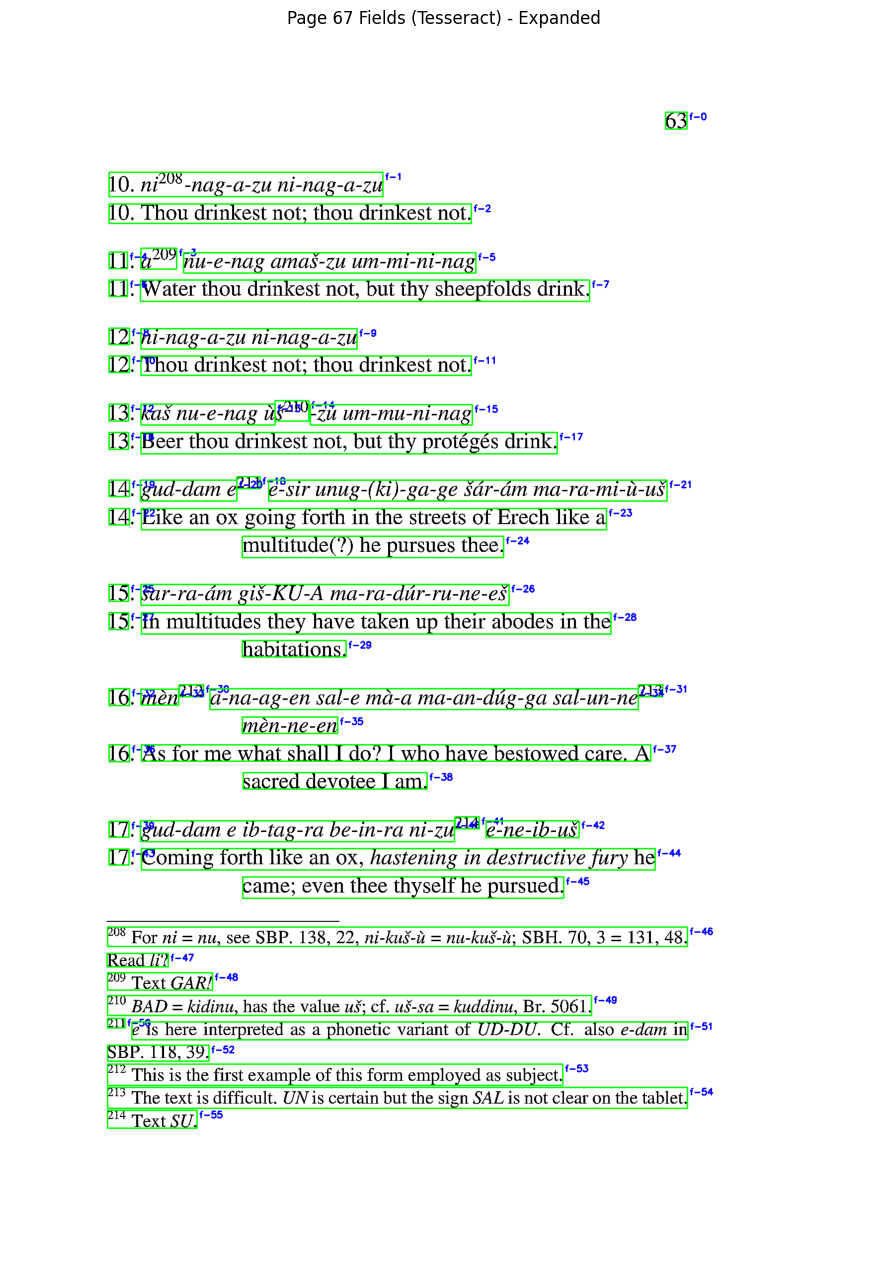

In [19]:
PAGE_NUMBER = 67
OUTPUT_FOLDER = "extracted_fields_mod"

extract_fields_mod(TEST_PDF_FILENAME, PAGE_NUMBER, OUTPUT_FOLDER, psm=11, show_bounds=True)

# Run OCR on a list of chapters
The `FRAGMENTS` is a dicitonary with chapters as keys and `(page_start, page_end)` tuples as values. Inside the for loop every chapter will be OCR-ed page by page and the algorithm will reconstruct the section text as a single spece-joined entity. Most of the time the paragraphs and columns are reconstructed properly. Each page is then stored as a separate CSV file inside the directory named after the chapter and stored inside a ZIP archive.

In [ ]:
PDF_FILEPATH = TEST_PDF_FILENAME

FRAGMENTS = {
    "Ashmolean-Prism-Col.II": (136, 143)
}

MODEL_HF_PATH='unsloth/GLM-OCR'

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.65G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/510 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/165 [00:00<?, ?B/s]

OCR Processing - pages...:   0%|          | 0/8 [00:00<?, ?it/s]

Running Tesseract layout analysis...
Extracted 33 fields using PyTesseract to 'Ashmolean-Prism-Col.II/fragments'.
Metadata saved to Ashmolean-Prism-Col.II/fragments/metadata.csv


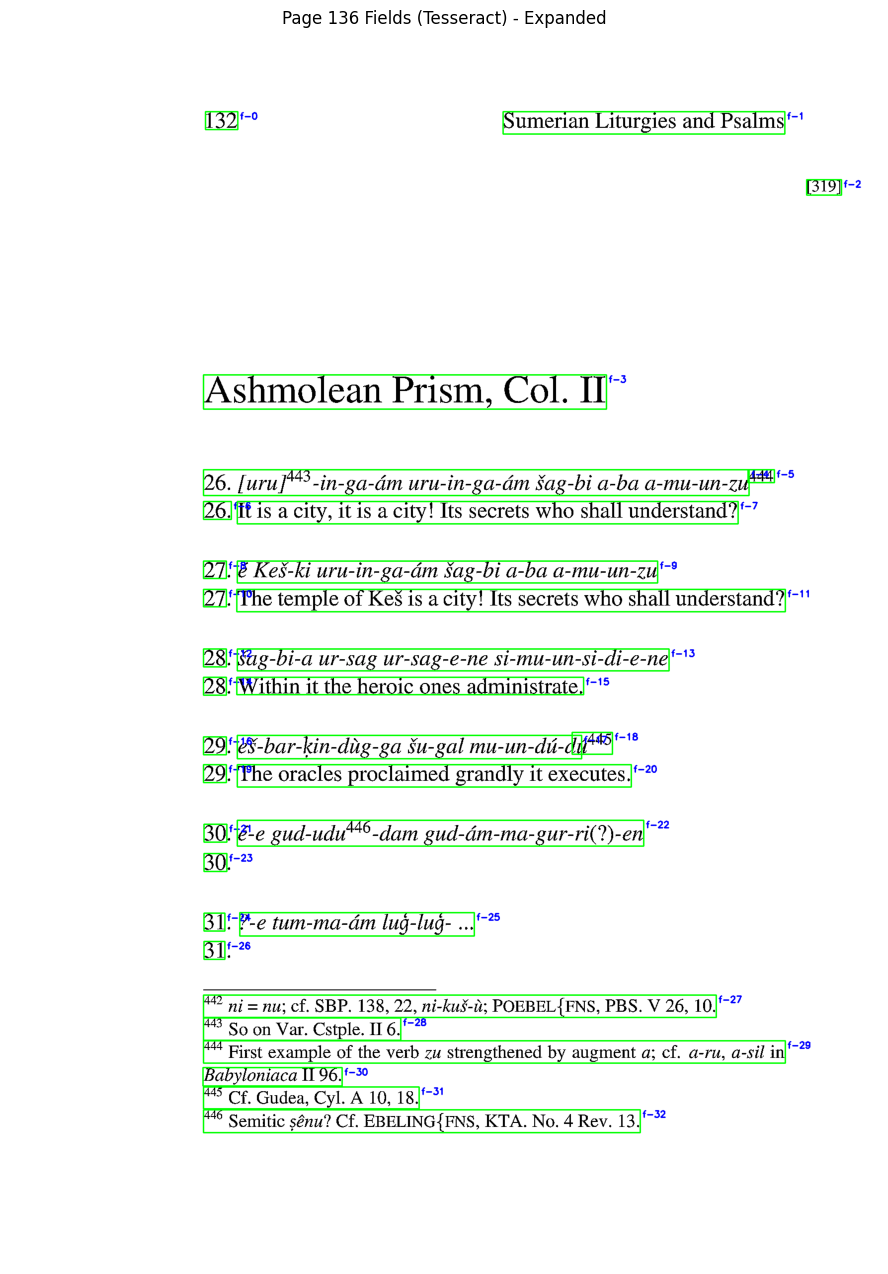

Saved 16 sections to 'Ashmolean-Prism-Col.II/fragments/meta_sections.csv'.
Processing 33 images from 'Ashmolean-Prism-Col.II/fragments' using cuda...
Running Tesseract layout analysis...
Extracted 31 fields using PyTesseract to 'Ashmolean-Prism-Col.II/fragments'.
Metadata saved to Ashmolean-Prism-Col.II/fragments/metadata.csv


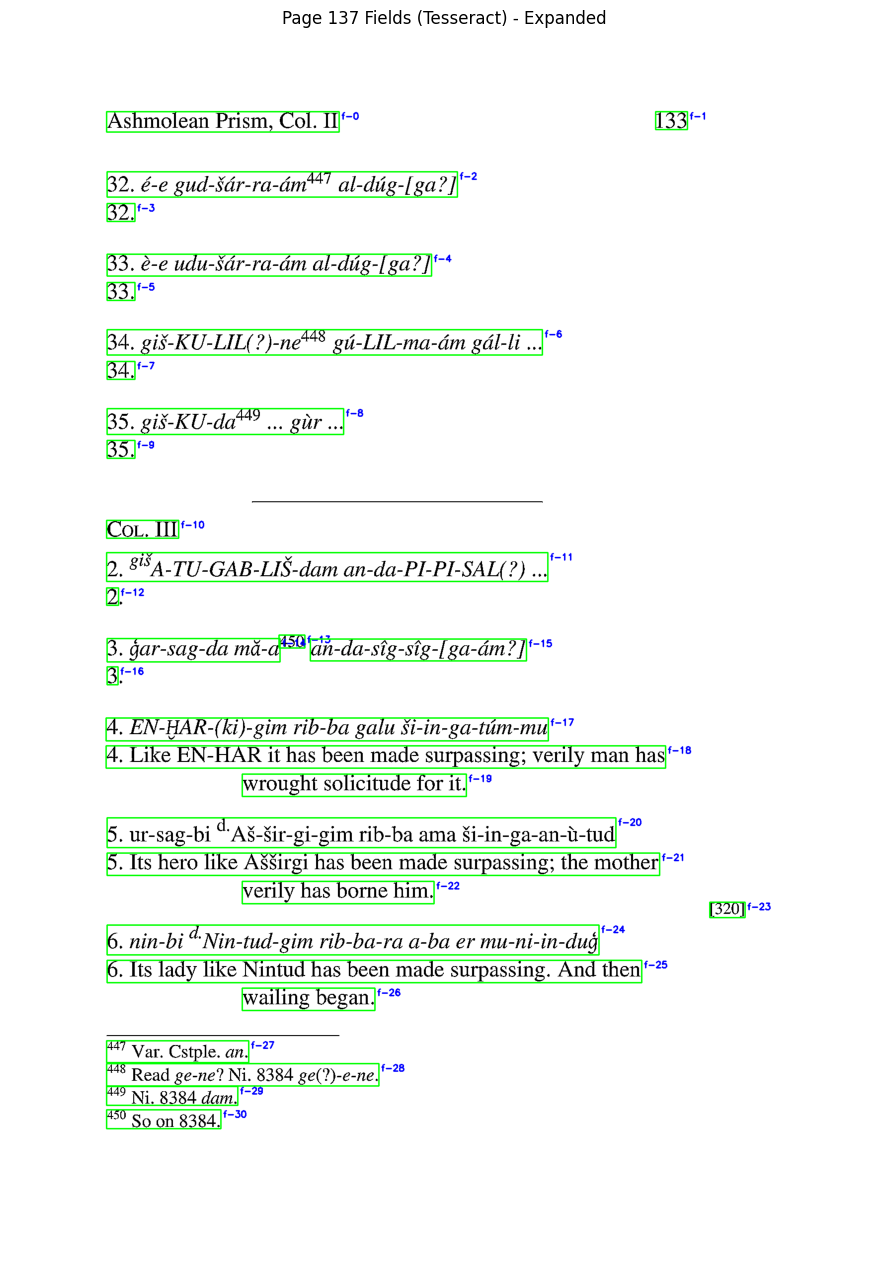

Saved 12 sections to 'Ashmolean-Prism-Col.II/fragments/meta_sections.csv'.
Processing 31 images from 'Ashmolean-Prism-Col.II/fragments' using cuda...
Running Tesseract layout analysis...
Extracted 43 fields using PyTesseract to 'Ashmolean-Prism-Col.II/fragments'.
Metadata saved to Ashmolean-Prism-Col.II/fragments/metadata.csv


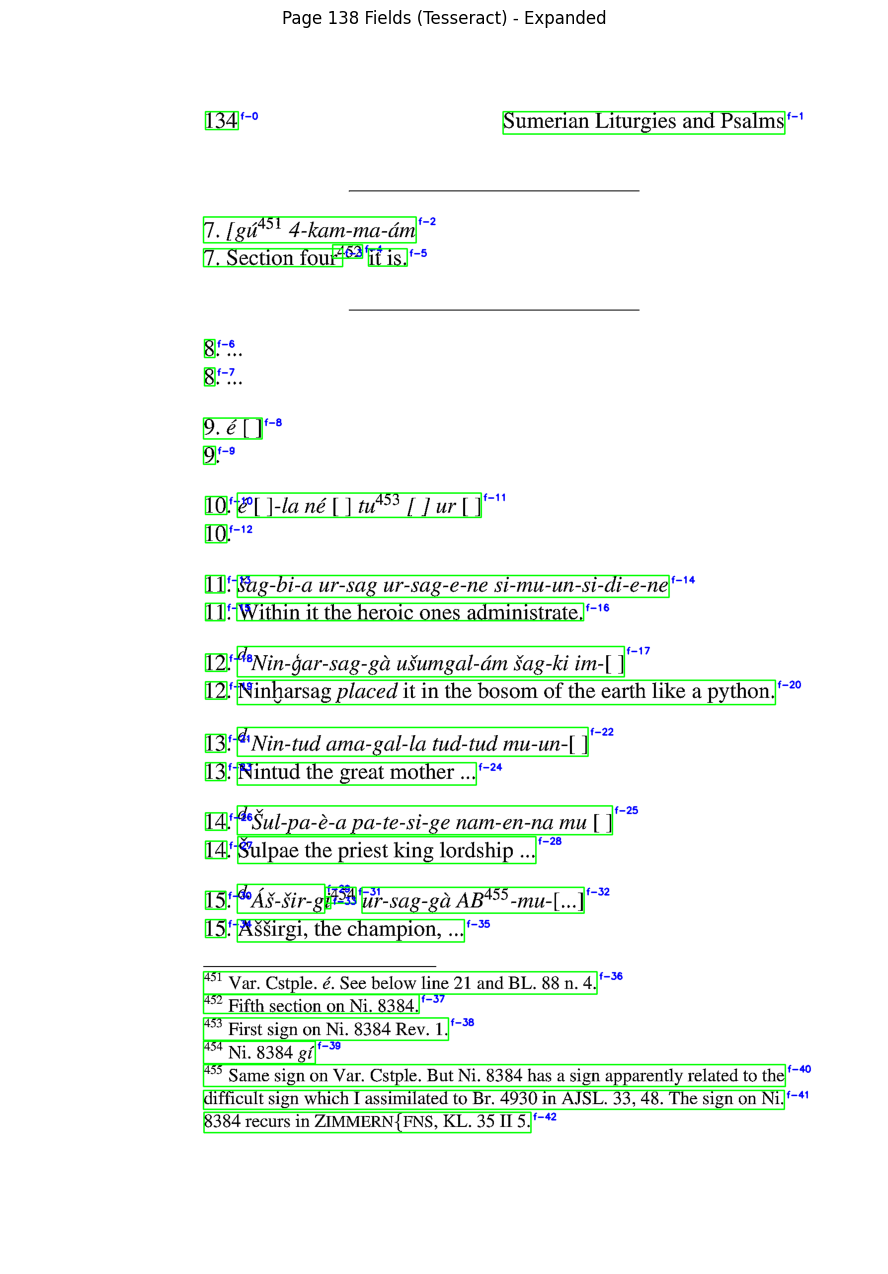

Saved 15 sections to 'Ashmolean-Prism-Col.II/fragments/meta_sections.csv'.
Processing 43 images from 'Ashmolean-Prism-Col.II/fragments' using cuda...
Running Tesseract layout analysis...
Extracted 56 fields using PyTesseract to 'Ashmolean-Prism-Col.II/fragments'.
Metadata saved to Ashmolean-Prism-Col.II/fragments/metadata.csv


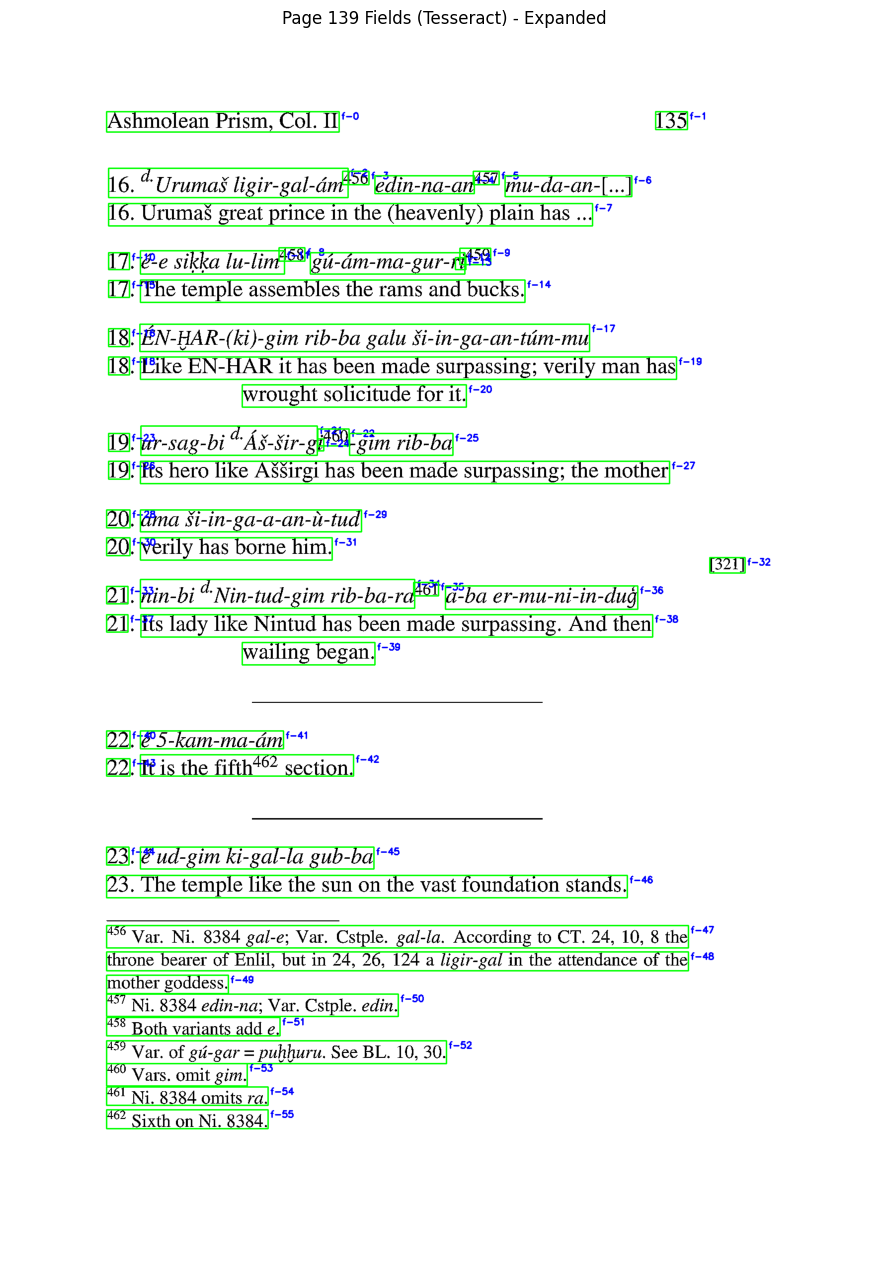

Saved 15 sections to 'Ashmolean-Prism-Col.II/fragments/meta_sections.csv'.
Processing 56 images from 'Ashmolean-Prism-Col.II/fragments' using cuda...
Running Tesseract layout analysis...
Extracted 38 fields using PyTesseract to 'Ashmolean-Prism-Col.II/fragments'.
Metadata saved to Ashmolean-Prism-Col.II/fragments/metadata.csv


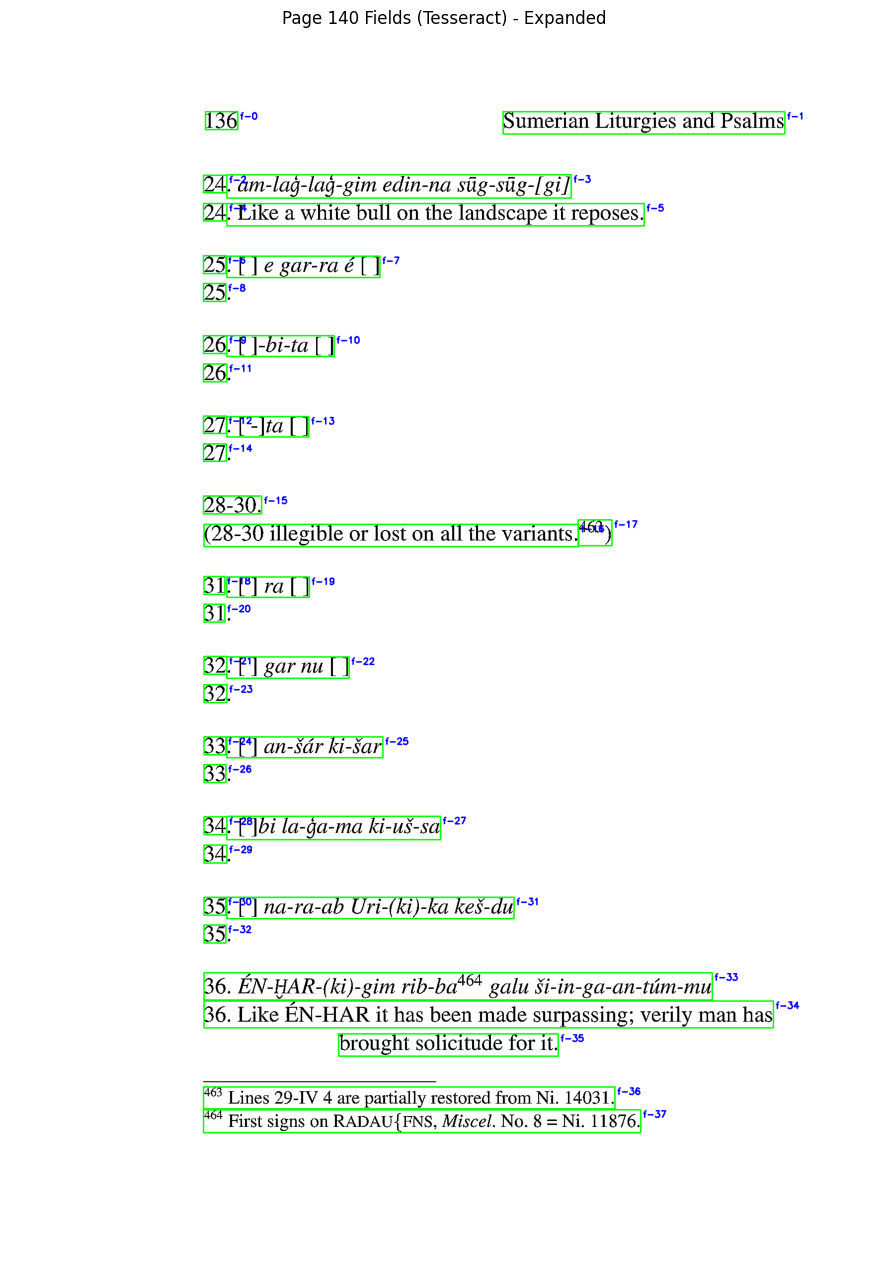

Saved 18 sections to 'Ashmolean-Prism-Col.II/fragments/meta_sections.csv'.
Processing 38 images from 'Ashmolean-Prism-Col.II/fragments' using cuda...
Running Tesseract layout analysis...
Extracted 35 fields using PyTesseract to 'Ashmolean-Prism-Col.II/fragments'.
Metadata saved to Ashmolean-Prism-Col.II/fragments/metadata.csv


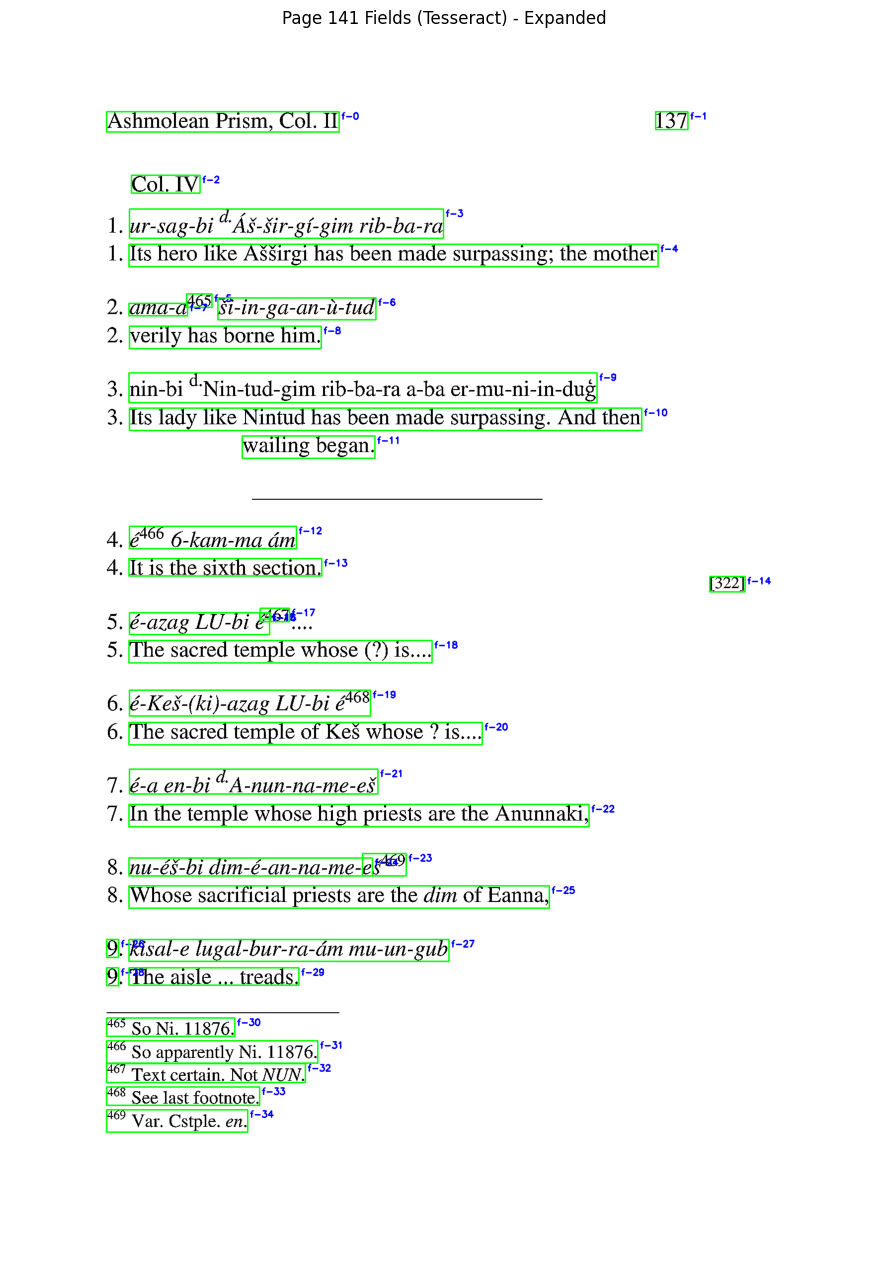

Saved 14 sections to 'Ashmolean-Prism-Col.II/fragments/meta_sections.csv'.
Processing 35 images from 'Ashmolean-Prism-Col.II/fragments' using cuda...
Running Tesseract layout analysis...
Extracted 51 fields using PyTesseract to 'Ashmolean-Prism-Col.II/fragments'.
Metadata saved to Ashmolean-Prism-Col.II/fragments/metadata.csv


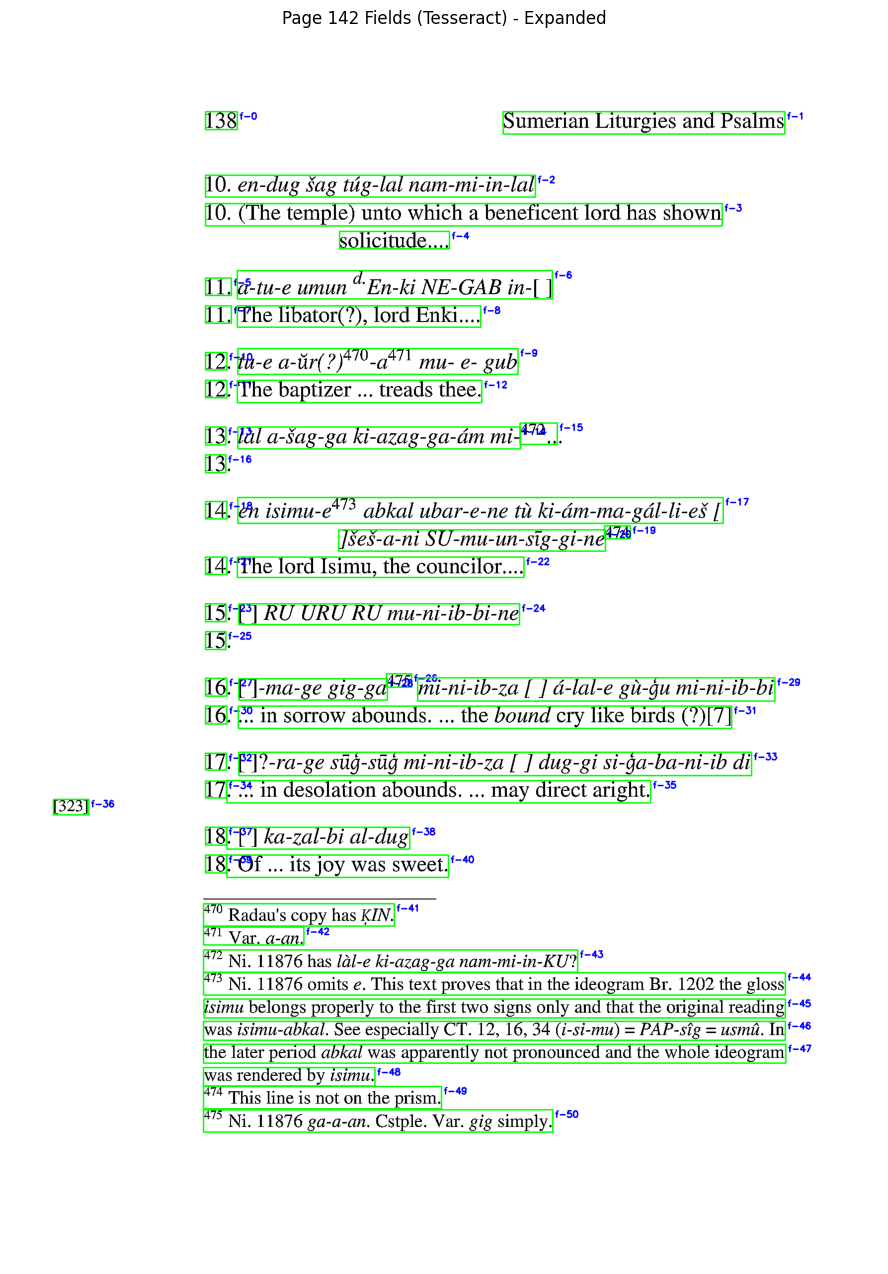

Saved 19 sections to 'Ashmolean-Prism-Col.II/fragments/meta_sections.csv'.
Processing 51 images from 'Ashmolean-Prism-Col.II/fragments' using cuda...
Running Tesseract layout analysis...
Extracted 32 fields using PyTesseract to 'Ashmolean-Prism-Col.II/fragments'.
Metadata saved to Ashmolean-Prism-Col.II/fragments/metadata.csv


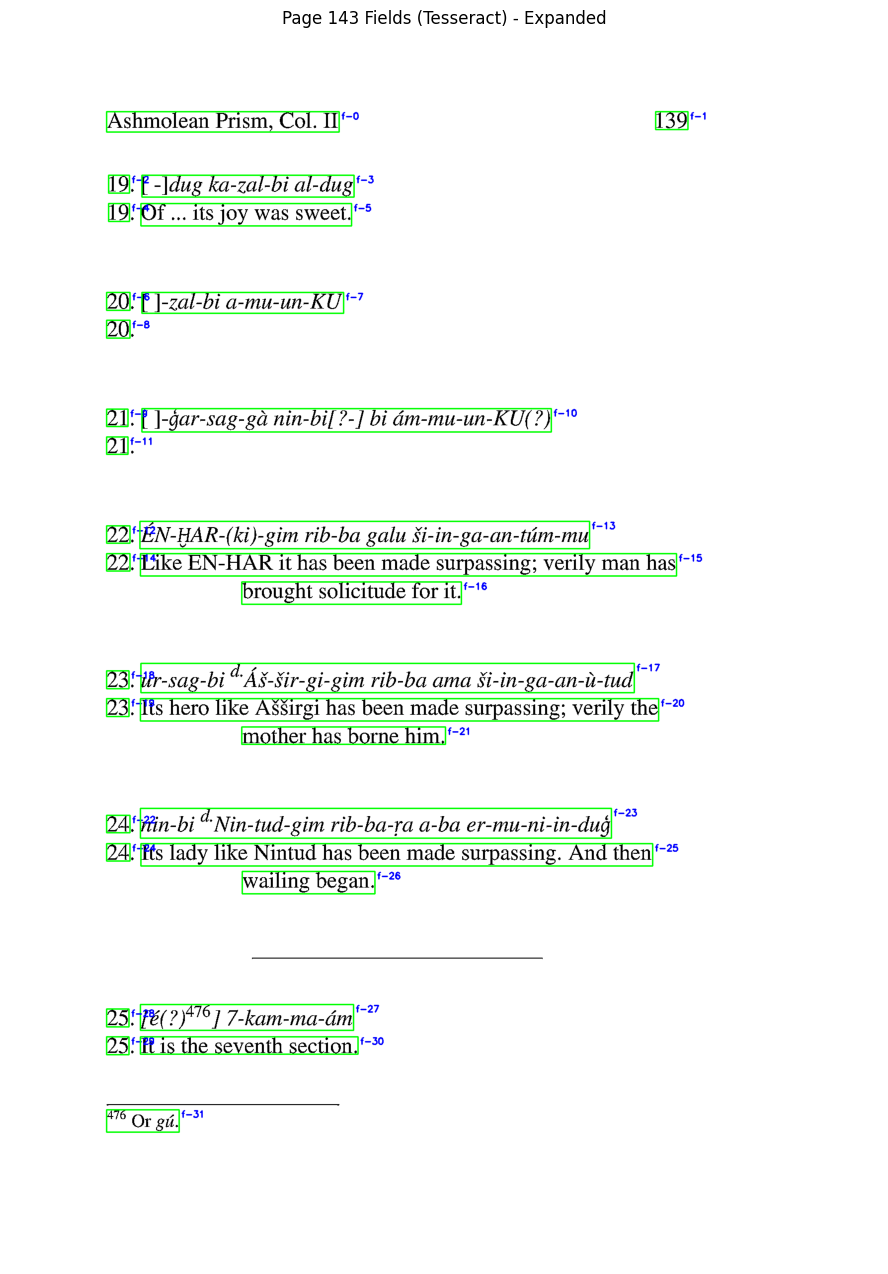

Saved 17 sections to 'Ashmolean-Prism-Col.II/fragments/meta_sections.csv'.
Processing 32 images from 'Ashmolean-Prism-Col.II/fragments' using cuda...
Zipping to Ashmolean-Prism-Col.II.zip...
Zipping complete.


In [14]:
for MAIN_DIRECTORY, (PAGE_START, PAGE_END) in FRAGMENTS.items():

    if not os.path.exists(MAIN_DIRECTORY):
        os.makedirs(MAIN_DIRECTORY)

    if not os.path.exists(f'{MAIN_DIRECTORY}/fragments'):
        os.makedirs(f'{MAIN_DIRECTORY}/fragments')

    PAGE_SPAN=[i for i in range(PAGE_START, PAGE_END+1, 1)]

    processor = AutoProcessor.from_pretrained(MODEL_HF_PATH, trust_remote_code=False)
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_HF_PATH,
        dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=False
    )
    for PAGE_NUMBER in tqdm(PAGE_SPAN, desc="OCR Processing - pages..."):
        if not os.listdir(f'{MAIN_DIRECTORY}/fragments'):
            shell_cmd = f"rm -r {MAIN_DIRECTORY}/fragments"
            !{shell_cmd}

        extract_fields_mod(PDF_FILEPATH,
                        PAGE_NUMBER,
                        f"{MAIN_DIRECTORY}/fragments",
                        psm=11,
                        show_bounds=True)

        df_mwe, df_sections = find_sections(metadata_fp=f'{MAIN_DIRECTORY}/fragments/metadata.csv',
                                            output_dir = f"{MAIN_DIRECTORY}/fragments")

        ocr_results_raw = batch_process_glm_ocr(input_dir=f"{MAIN_DIRECTORY}/fragments",
                                                model=model,
                                                processor=processor,
                                                model_path=MODEL_HF_PATH)

        df_mwe['text'] = df_mwe.apply(lambda x: f"p-{x['page_num']}_f-{x['field_num']}", axis=1).map(ocr_results_raw)

        pd.concat(
            [
                pd.Series(df_sections['section_id'], name='page_num').apply(lambda x: PAGE_NUMBER),
                df_sections,
                df_mwe.groupby('section_id')[['text']].apply(lambda x: ' '.join(x['text'])).rename('text')
            ], axis=1
        ).to_csv(os.path.join(MAIN_DIRECTORY, f"OCR_results_p-{PAGE_NUMBER}.csv"), index=False)

    save_images_as_zip(MAIN_DIRECTORY)